In [30]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

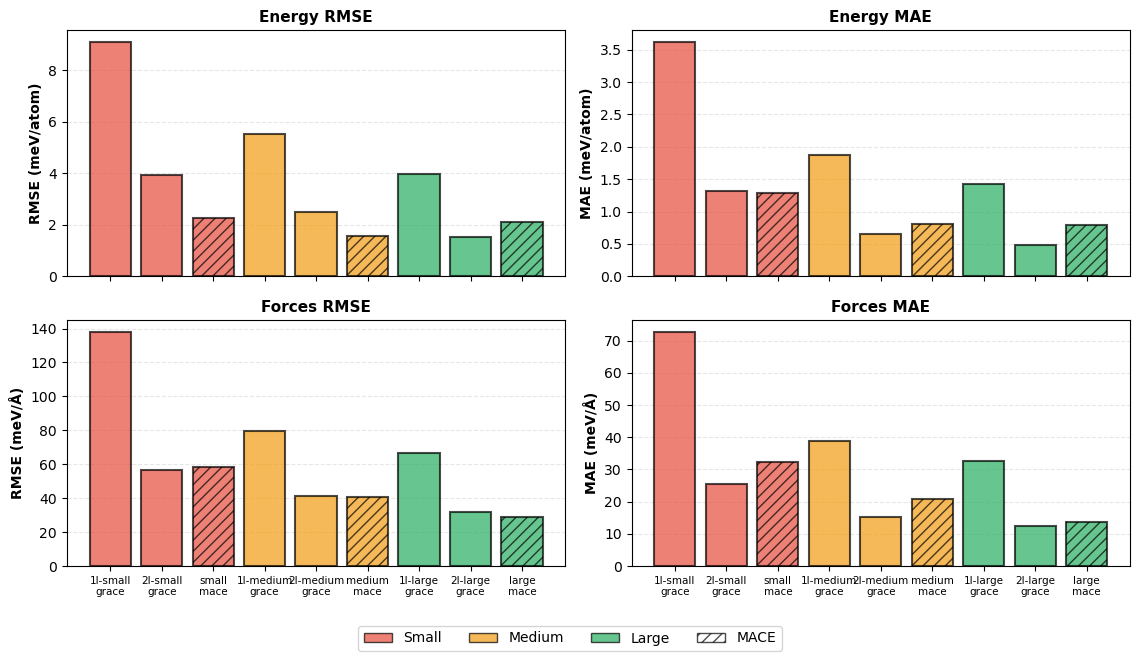

In [ ]:
##### Final Plots for Energies and Forces #####

# Load data
# There are two possible files, energies_per_atom -> structures seen by GRACE and MACE, energies_per_atom_ood -> structure NOT seen by GRACE
df = pd.read_csv('energies_per_atom_ood.csv')

# Extract layers and size
df['layers'] = df['size'].str.extract(r'(\d+l)')[0]
df['model_size'] = df['size'].str.extract(r'_(\w+)$')[0]

# Filter for 2-layer models only (2l GRACE and MACE)
# df = df[(df['layers'] == '2l') | (df['model'] == 'mace')].copy()

# Sort order: group by size (small, medium, large), then within each size: GRACE first, then MACE
def get_sort_key(row):
    size_order = {'small': 0, 'medium': 1, 'large': 2}
    model_order = {'grace': 0, 'mace': 1}
    return (size_order[row['model_size']], model_order[row['model']])

df['sort_keys'] = df.apply(get_sort_key, axis=1)
df = df.sort_values('sort_keys').reset_index(drop=True)
df = df.drop('sort_keys', axis=1)

# Create x-axis labels: include size and layer info
df['x_label'] = df.apply(
    lambda row: f"{row['model_size']}\n{row['model']}" if row['model'] == 'mace' 
    else f"{row['layers']}-{row['model_size']}\n{row['model']}", 
    axis=1
)

# Create 2x2 subplot with shared x-axis
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.5), sharex=True)
axes = axes.flatten()

# Metrics to plot: (column_name, title, ylabel, unit)
metrics = [
    ('energy_rmse_meV', 'Energy RMSE', 'RMSE (meV/atom)'),
    ('energy_mae_meV', 'Energy MAE', 'MAE (meV/atom)'),
    ('forces_rmse_meV_per_A', 'Forces RMSE', 'RMSE (meV/Å)'),
    ('forces_mae_meV_per_A', 'Forces MAE', 'MAE (meV/Å)')
]

# Color mapping for sizes
size_colors = {'small': '#e74c3c', 'medium': '#f39c12', 'large': '#27ae60'}

# Plot each metric
for idx, (metric, title, ylabel) in enumerate(metrics):
    ax = axes[idx]
    
    # Get unique x positions
    x_positions = np.arange(len(df))
    
    # Create bars with colors based on size
    colors = [size_colors[size] for size in df['model_size']]
    
    # Highlight MACE models with hatching pattern
    hatches = ['///' if model == 'mace' else '' for model in df['model']]
    
    bars = ax.bar(x_positions, df[metric], color=colors, alpha=0.7, 
                  edgecolor='black', linewidth=1.5)
    
    # Apply hatching to MACE bars
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    
    # Customize plot
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(df['x_label'], fontsize=7.5, rotation=0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

# Create legend for sizes and MACE pattern at the bottom
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=size_colors[size], label=size.capitalize(), 
                         edgecolor='black', alpha=0.7) 
                   for size in ['small', 'medium', 'large']]
# Add MACE hatching pattern to legend
legend_elements.append(Patch(facecolor='white', label='MACE', 
                             edgecolor='black', hatch='///', alpha=0.7))
fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
           bbox_to_anchor=(0.5, -0.02), fontsize=10, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig("energies_ood_all.pdf", bbox_inches='tight')
plt.show()